In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1

***a)***

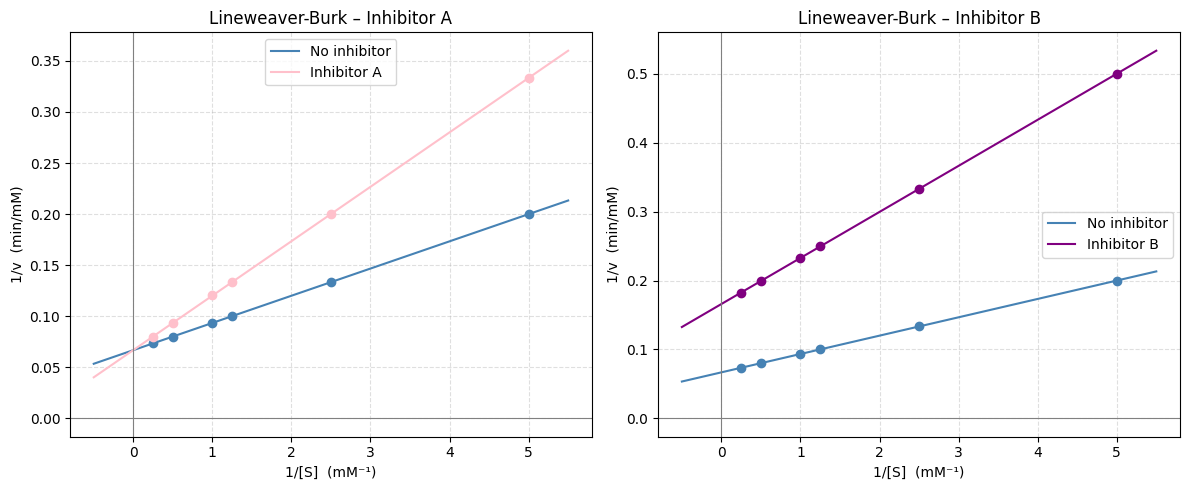

In [ ]:
S = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0])  # mM
v_no_inh = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6])   # mM/min
v_inh_A  = np.array([3.0, 5.0, 7.5,  8.3, 10.7, 12.5])
v_inh_B  = np.array([2.0, 3.0, 4.0,  4.3,  5.0,  5.5])

inv_S      = 1 / S
inv_v_no   = 1 / v_no_inh
inv_v_A    = 1 / v_inh_A
inv_v_B    = 1 / v_inh_B

def linreg(x, y):
    coeffs = np.polyfit(x, y, 1)  # [slope, intercept]
    return coeffs

def plot_LB(ax, inv_S, inv_v_no, inv_v_inh, inh_label, color_inh):
    c_no  = linreg(inv_S, inv_v_no)
    c_inh = linreg(inv_S, inv_v_inh)

    x_fit = np.linspace(-0.5, max(inv_S) * 1.1, 200)

    ax.scatter(inv_S, inv_v_no,  color='steelblue', zorder=5)
    ax.scatter(inv_S, inv_v_inh, color=color_inh,   zorder=5)

    ax.plot(x_fit, np.polyval(c_no,  x_fit), color='steelblue', label='No inhibitor')
    ax.plot(x_fit, np.polyval(c_inh, x_fit), color=color_inh,   label=inh_label)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)

    ax.set_xlabel('1/[S]  (mM⁻¹)')
    ax.set_ylabel('1/v  (min/mM)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_LB(ax1, inv_S, inv_v_no, inv_v_A, 'Inhibitor A', 'pink')
ax1.set_title('Lineweaver-Burk – Inhibitor A')

plot_LB(ax2, inv_S, inv_v_no, inv_v_B, 'Inhibitor B', 'purple')
ax2.set_title('Lineweaver-Burk – Inhibitor B')

plt.tight_layout()
plt.savefig('lineweaver_burk_1a.png', dpi=150)
plt.show()

The Michaelis-Menten equation describes the reaction rate as a function of substrate concentration:

$$v = \frac{V_{max}[S]}{K_M + [S]}$$

To linearize this equation, the Lineweaver-Burk (double reciprocal) transformation was applied by taking the inverse of both sides:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

This yields a linear equation of the form $y = ax + b$, where:
- **slope** = $K_M / V_{max}$
- **y-intercept** = $1 / V_{max}$
- **x-intercept** = $-1 / K_M$

For each condition (no inhibitor, inhibitor A at concentration $C_A$, inhibitor B at concentration $C_B$), 1/v was plotted against 1/[S] and a linear regression was performed using numpy `polyfit`. Inhibitor A and inhibitor B are shown on separate graphs to facilitate visual comparison. The lines were extrapolated into the negative 1/[S] region to allow identification of the x-intercept ($-1/K_M$) and y-intercept ($1/V_{max}$).

Both plots show a good linear fit of the experimental data, confirming that the enzyme follows Michaelis-Menten kinetics under all tested conditions. In the presence of inhibitor A, the slope increases compared to the no-inhibitor case while the lines appear to converge toward the same y-intercept, suggesting that $V_{max}$ is preserved.
both the slope and the y-intercept increase, indicating a decrease in $V_{max}$ while $K_M$ remains approximately constant.
These observations suggest that inhibitor A affects substrate binding, whereas inhibitor B affects catalytic efficiency. The inhibition types will be confirmed quantitatively in parts b and c.

***b)***

In [2]:
c_no = linreg(inv_S, inv_v_no)
c_A  = linreg(inv_S, inv_v_A)
c_B  = linreg(inv_S, inv_v_B)

def kinetic_params(coeffs, label):
    Vmax = 1 / coeffs[1]
    Km   = coeffs[0] * Vmax
    print(f"{label:30s} | Vmax = {Vmax:.3f} mM/min | Km = {Km:.3f} mM")
    return Vmax, Km

print(f"{'':<30} | {'Vmax':^20} | {'Km':^12}")
print("-" * 65)
Vmax_no, Km_no = kinetic_params(c_no, "No inhibitor")
Vmax_A,  Km_A  = kinetic_params(c_A,  "Inhibitor A")
Vmax_B,  Km_B  = kinetic_params(c_B,  "Inhibitor B")

                               |         Vmax         |      Km     
-----------------------------------------------------------------
No inhibitor                   | Vmax = 14.978 mM/min | Km = 0.399 mM
Inhibitor A                    | Vmax = 14.964 mM/min | Km = 0.798 mM
Inhibitor B                    | Vmax = 6.025 mM/min | Km = 0.403 mM




The kinetic parameters were extracted directly from the linear regression coefficients
obtained in part a. From the Lineweaver-Burk equation:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

the parameters are obtained as follows:

$$V_{max} = \frac{1}{\text{intercept}} \qquad K_M = \text{slope} \times V_{max}$$

This approach assumes that the enzyme follows Michaelis-Menten kinetics, which means that the
reaction involves a single substrate, a single enzyme-substrate complex, and that the
quasi-steady state assumption (QSSA) holds. It also assumes that the experimental data
are free of significant measurement noise, as the Lineweaver-Burk transformation
amplifies errors at low substrate concentrations (high 1/[S] values) due to the double
reciprocal. The linear regression was performed using numpy `polyfit`, which minimizes
the sum of squared residuals.

For inhibitor A, $V_{max}$ remains essentially unchanged (14.964 vs 14.978 mM/min)
while $K_M$ doubles from 0.399 to 0.798 mM. This means the enzyme retains its maximum
catalytic capacity but requires a higher substrate concentration to reach half-maximal
velocity, indicating reduced apparent affinity for the substrate.

For inhibitor B, $K_M$ remains nearly identical (0.403 vs 0.399 mM) while $V_{max}$
drops significantly from 14.978 to 6.025 mM/min, meaning the enzyme-substrate affinity
is unaffected but the overall catalytic throughput is reduced.

These observations are consistent with the visual inspection of the Lineweaver-Burk
plots in part a, and will be used in part c to formally identify the inhibition type.


***c)***

In [3]:
print("Inhibitor identification based on Lineweaver-Burk equations")

# Slopes and intercepts
slope_no, intercept_no = c_no
slope_A, intercept_A = c_A
slope_B, intercept_B = c_B

def classify_inhibitor(slope_i, intercept_i, slope_no, intercept_no, name):
    slope_changed = not np.isclose(slope_i, slope_no, rtol=0.05)
    intercept_changed = not np.isclose(intercept_i, intercept_no, rtol=0.05)

    print(f"\n{name}")
    print(f"  Slope changed?      {slope_changed} ({slope_no:.4f} -> {slope_i:.4f})")
    print(f"  Intercept changed?  {intercept_changed} ({intercept_no:.4f} -> {intercept_i:.4f})")

    if slope_changed and not intercept_changed:
        print("  => Competitive inhibition")
    elif not slope_changed and intercept_changed:
        print("  => Uncompetitive inhibition")
    elif slope_changed and intercept_changed:
        print("  => Non-competitive inhibition")
    else:
        print("  => No inhibition or inconclusive")

print(f"{'':<20} | {'Slope (Km/Vmax)':>16} | {'Intercept (1/Vmax)':>18}")
print("-" * 62)
print(f"{'No inhibitor':<20} | {slope_no:>16.4f} | {intercept_no:>18.4f}")
print(f"{'Inhibitor A':<20} | {slope_A:>16.4f} | {intercept_A:>18.4f}")
print(f"{'Inhibitor B':<20} | {slope_B:>16.4f} | {intercept_B:>18.4f}")

classify_inhibitor(slope_A, intercept_A, slope_no, intercept_no, "Inhibitor A")
classify_inhibitor(slope_B, intercept_B, slope_no, intercept_no, "Inhibitor B")

Inhibitor identification based on Lineweaver-Burk equations
                     |  Slope (Km/Vmax) | Intercept (1/Vmax)
--------------------------------------------------------------
No inhibitor         |           0.0266 |             0.0668
Inhibitor A          |           0.0533 |             0.0668
Inhibitor B          |           0.0668 |             0.1660

Inhibitor A
  Slope changed?      True (0.0266 -> 0.0533)
  Intercept changed?  False (0.0668 -> 0.0668)
  => Competitive inhibition

Inhibitor B
  Slope changed?      True (0.0266 -> 0.0668)
  Intercept changed?  True (0.0668 -> 0.1660)
  => Non-competitive inhibition


To determine the type of inhibition, the slope and y-intercept of the Lineweaver-Burk plots were compared between the inhibited and uninhibited conditions.

From the Lineweaver-Burk equation:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

the effects of different types of inhibitors can be identified as follows:
- **Competitive inhibition**: slope increases, y-intercept remains constant ($V_{max}$ unchanged, $K_M$ increases)
- **Uncompetitive inhibition**: slope remains constant, y-intercept increases (parallel lines, $V_{max}$ decreases, $K_M$ decreases)
- **Non-competitive inhibition**: both slope and y-intercept increase ($V_{max}$ decreases, $K_M$ unchanged)

For inhibitor A, the slope increases significantly compared to the no-inhibitor condition, while the y-intercept remains unchanged. This indicates that $V_{max}$ is constant and $K_M$ increases. Therefore, inhibitor A is classified as a **competitive inhibitor**, suggesting that it competes with the substrate for binding to the active site.

For inhibitor B, both the slope and the y-intercept increase relative to the no-inhibitor condition. This indicates a decrease in $V_{max}$, while $K_M$ remains approximately constant. The lines are not parallel, which rules out uncompetitive inhibition. Therefore, inhibitor B is classified as a **non-competitive inhibitor**, suggesting that it affects the catalytic activity of the enzyme rather than substrate binding.

These conclusions are consistent with the theoretical behavior expected from Lineweaver-Burk analysis.

***d)***

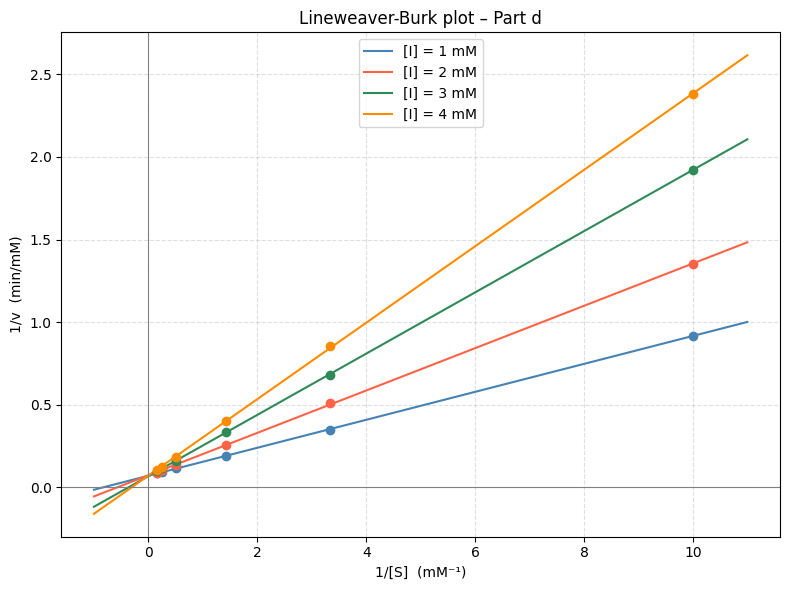

[I] (mM)     |      Slope |    Intercept
----------------------------------------
1            |     0.0847 |       0.0690
2            |     0.1283 |       0.0720
3            |     0.1855 |       0.0666
4            |     0.2315 |       0.0699


In [ ]:
S_d = np.array([0.1, 0.3, 0.7, 2.0, 4.0, 6.0])  # mM
I_conc = np.array([1, 2, 3, 4])  # mM

v_d = np.array([
    [1.09, 0.74, 0.52, 0.42],
    [2.89, 1.96, 1.47, 1.17],
    [5.24, 3.89, 3.01, 2.51],
    [8.85, 7.40, 6.31, 5.43],
    [10.89, 9.82, 8.76, 8.07],
    [12.11, 11.36, 10.02, 9.37]
])  # rows = [S], cols = [I]

# Lineweaver-Burk transformation
inv_S_d = 1 / S_d
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 6))

slopes     = []
intercepts = []

for i, I in enumerate(I_conc):
    inv_v = 1 / v_d[:, i]
    coeffs = np.polyfit(inv_S_d, inv_v, 1)
    slopes.append(coeffs[0])
    intercepts.append(coeffs[1])

    x_fit = np.linspace(-1, max(inv_S_d) * 1.1, 200)
    ax.scatter(inv_S_d, inv_v, color=colors[i], zorder=5)
    ax.plot(x_fit, np.polyval(coeffs, x_fit),
            color=colors[i], label=f'[I] = {I} mM')

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('1/[S]  (mM⁻¹)')
ax.set_ylabel('1/v  (min/mM)')
ax.set_title('Lineweaver-Burk plot – Part d')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('lineweaver_burk_1d.png', dpi=150)
plt.show()

# Print slopes and intercepts
print(f"{'[I] (mM)':<12} | {'Slope':>10} | {'Intercept':>12}")
print("-" * 40)
for i, I in enumerate(I_conc):
    print(f"{I:<12} | {slopes[i]:>10.4f} | {intercepts[i]:>12.4f}")

The Lineweaver-Burk transformation was applied to the data obtained at different inhibitor concentrations ([I] = 1–4 mM) in order to analyze the effect of inhibitor I on enzyme kinetics.

The double reciprocal form of the Michaelis-Menten equation is:

$$\frac{1}{v} = \frac{K_M}{V_{max}} \cdot \frac{1}{[S]} + \frac{1}{V_{max}}$$

For each inhibitor concentration, 1/v was plotted against 1/[S], and linear regression was performed to obtain the slope and y-intercept.

The following values were obtained:

| [I] (mM) | Slope (Km/Vmax) | Intercept (1/Vmax) |
|----------|----------------|-------------------|
| 1        | 0.0847         | 0.0690            |
| 2        | 0.1283         | 0.0720            |
| 3        | 0.1855         | 0.0666            |
| 4        | 0.2315         | 0.0699            |

From visual inspection of the Lineweaver-Burk plot, the lines corresponding to different inhibitor concentrations intersect near the y-axis, while the slope increases with increasing [I]. The y-intercept remains approximately constant.

This indicates that $V_{max}$ remains unchanged, while $K_M$ increases with inhibitor concentration. Therefore, inhibitor I is classified as a **competitive inhibitor**.

This behavior is consistent with competitive inhibition, where the inhibitor competes with the substrate for binding to the active site, and its effect can be overcome at high substrate concentrations.

Fit of slope vs [I]: slope = 0.0498, intercept = 0.0331
=> KI = 0.0331 / 0.0498 = 0.665 mM

Estimated Vmax = 14.414 mM/min  (from mean intercept)
Estimated Km   = 0.477 mM


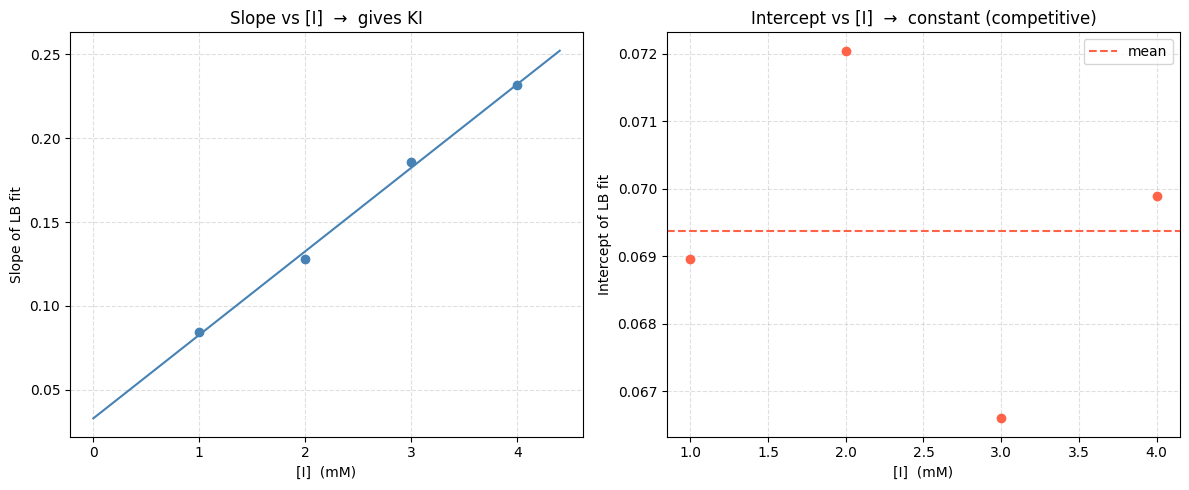

In [5]:
c_slope = np.polyfit(I_conc, slopes, 1)

KI = c_slope[1] / c_slope[0]

print(f"Fit of slope vs [I]: slope = {c_slope[0]:.4f}, intercept = {c_slope[1]:.4f}")
print(f"=> KI = {c_slope[1]:.4f} / {c_slope[0]:.4f} = {KI:.3f} mM")

Vmax_d = 1 / np.mean(intercepts)
Km_d   = c_slope[1] * Vmax_d

print(f"\nEstimated Vmax = {Vmax_d:.3f} mM/min  (from mean intercept)")
print(f"Estimated Km   = {Km_d:.3f} mM")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_I = np.linspace(0, max(I_conc) * 1.1, 100)

ax1.scatter(I_conc, slopes, color='steelblue', zorder=5)
ax1.plot(x_I, np.polyval(c_slope, x_I), color='steelblue')
ax1.set_xlabel('[I]  (mM)')
ax1.set_ylabel('Slope of LB fit')
ax1.set_title('Slope vs [I]  →  gives KI')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.scatter(I_conc, intercepts, color='tomato', zorder=5)
ax2.axhline(np.mean(intercepts), color='tomato', linestyle='--', label='mean')
ax2.set_xlabel('[I]  (mM)')
ax2.set_ylabel('Intercept of LB fit')
ax2.set_title('Intercept vs [I]  →  constant (competitive)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('KI_estimation.png', dpi=150)
plt.show()

To estimate the inhibition constant $K_I$, the variation of the Lineweaver-Burk slope as a function of inhibitor concentration [I] was analyzed.

For competitive inhibition, the slope of the Lineweaver-Burk plot is given by:

$$
\text{slope} = \frac{K_M}{V_{max}} \left(1 + \frac{[I]}{K_I} \right)
$$

This predicts a linear relationship between slope and [I]:

$$
\text{slope} = a [I] + b
$$

where:
- $b = \frac{K_M}{V_{max}}$
- $a = \frac{K_M}{V_{max} K_I}$

A linear regression of slope vs [I] gave:
- slope = 0.0498  
- intercept = 0.0331  

Thus:

$$
K_I = \frac{b}{a} = \frac{0.0331}{0.0498} \approx 0.665 \ \text{mM}
$$

In addition, the intercept of the Lineweaver-Burk plots was plotted as a function of [I]. The intercept remains approximately constant across all inhibitor concentrations, indicating that $1/V_{max}$ does not change.

This confirms that $V_{max}$ is unchanged, which is characteristic of **competitive inhibition**.

Both the slope analysis and the constant intercept support the conclusion that inhibitor I is competitive, and the estimated value of $K_I$ reflects its binding affinity.

# Exericse 2- Inhibition of lactic acid 

***a)***

**Assumptions**

-The experiment is carried out under substrate saturation, so the substrate concentration does not limit the growth rate.

-Lactic acid is treated as a weak acid, meaning it exists in equilibrium between its undissociated form (HA) and its dissociated form (A⁻).

-Only the undissociated form (HA) is assumed to inhibit growth, since it can diffuse through the cell membrane. The dissociated form (A⁻) is neglected.
-The pH is constant and the acid–base equilibrium is established.

-The system volume is constant.

**Methodology**

The concentrations provided are given in g/L and are first converted into molar units (mM) using the molar mass of lactic acid ($M = 90.08$ g/mol):

$$
P_{total} = \frac{p}{M} \times 1000
$$

Since lactic acid is a weak acid, it partially dissociates in solution according to:

$$
HA \rightleftharpoons H^+ + A^-
$$

The fraction of lactic acid that remains in the undissociated form at the given pH is determined using the Henderson–Hasselbalch relation:

$$
\text{fraction} = \frac{1}{1 + 10^{pH - pK_a}}
$$

with $pH = 6.3$ and $pK_a = 3.88$.

The concentration of undissociated acid is then:

$$
P = P_{total} \times \text{fraction}
$$

Finally, the relative specific growth rate is calculated as:

$$
\frac{\mu(P)}{\mu(0)}
$$

where $\mu(0)$ corresponds to the growth rate in the absence of lactic acid.


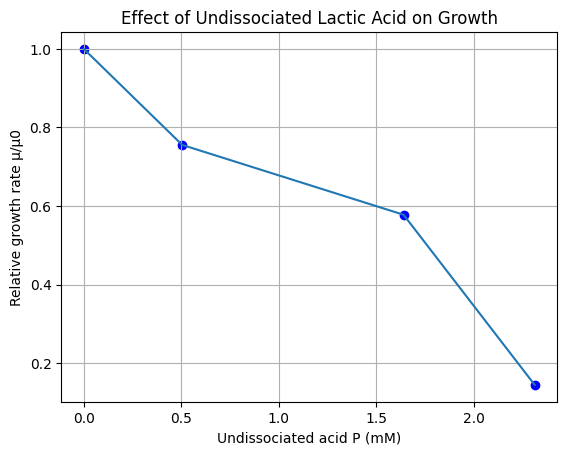

In [ ]:
p_gL = np.array([0, 12, 39, 55])   # (g/L)
mu = np.array([0.9, 0.68, 0.52, 0.13])

pH = 6.3
pKa = 3.88
M = 90.08   # g/mol

p_molL = p_gL / M
p_mM = p_molL * 1000


fraction = 1 / (1 + 10**(pH - pKa))
P = p_mM * fraction

mu_rel = mu / mu[0]

plt.figure()
plt.scatter(P, mu_rel, color='blue')
plt.plot(P, mu_rel)

plt.xlabel("Undissociated acid P (mM)")
plt.ylabel("Relative growth rate μ/μ0")
plt.title("Effect of Undissociated Lactic Acid on Growth")
plt.grid()

plt.show()

**Results and Interpretation**

The relative specific growth rate $\mu / \mu_0$ decreases monotonically with increasing concentration of undissociated lactic acid $P$, confirming its inhibitory effect on bacterial growth.
At low concentrations ($P \approx 0.5$ mM), the decrease in growth rate remains moderate (around 25% reduction), indicating that the cells can still sustain growth despite the presence of the inhibitor. However, as $P$ increases further, the inhibition becomes significantly stronger. In particular, between $P \approx 1.5$ mM and $P \approx 2.3$ mM, a sharp drop in growth rate is observed, suggesting a stronger sensitivity of the system at higher concentrations.
The overall trend is clearly non-linear, with an accelerating decrease in $\mu / \mu_0$ as $P$ increases. This indicates that the inhibitory effect is not simply proportional to the concentration of undissociated acid, but becomes more pronounced at higher levels.
These observations are consistent with a dose-dependent inhibition mechanism and suggest that a non-linear inhibition model, such as the one introduced in part (b), will be more appropriate to describe the system.

It should be noted that at pH = 6.3, which is well above the pKa of 3.88, only a very small fraction of the total lactic acid remains undissociated. Despite this, even these small concentrations are sufficient to cause strong inhibition, highlighting the high toxicity of the undissociated acid form at the intracellular level.

***b)***

**Assumptions**

* The system operates under substrate saturation, so the Monod term satisfies
  $$
  \frac{S}{K_M + S} \approx 1
  $$
  and does not influence the growth rate.

* The observed decrease in growth rate is solely attributed to inhibition by the undissociated lactic acid concentration $P$, as determined in part (a).

* The inhibition follows the proposed kinetic model:
  $$
  \mu = \mu_{\max} \cdot \frac{S}{K_M + S} \cdot \frac{1}{1 + \frac{P}{K_I}}
  $$

* Under substrate saturation, this reduces to:
  $$
  \mu = \mu_{\max} \cdot \frac{1}{1 + \frac{P}{K_I}}
  $$

* At $P = 0$, no inhibitor is present in the system. Substituting $P = 0$ into the model gives:
$$ 
μ=\mu_{\max}⋅\frac{1}{1+0}=\mu_{\max}
​$$
 
This shows that, in the absence of inhibition, the growth rate reaches its maximum value. Therefore, the experimental value measured at $P = 0$ corresponds directly to $\mu_{\max}$.

**Methodology**

The simplified inhibition model is used to describe the dependence of the growth rate on the concentration of undissociated lactic acid:

$$
\mu = \mu_{\max} \cdot \frac{1}{1 + \frac{P}{K_I}}
$$

The value of $\mu_{\max}$ is obtained directly from the experimental data at $P = 0$.
To estimate the inhibition constant $K_I$, the model is rearranged into a linear form. Dividing both sides by $\mu$ gives:

$$
\frac{\mu_{\max}}{\mu} = 1 + \frac{P}{K_I}
$$

which can be rewritten as:

$$
\frac{\mu_{\max}}{\mu} - 1 = \frac{P}{K_I}
$$

This expression defines a linear relationship between $\left(\frac{\mu_{\max}}{\mu} - 1\right)$ and $P$, where the slope corresponds to $\frac{1}{K_I}$.

A linear regression is therefore performed on the transformed data using a least-squares approach (implemented via `polyfit`). The slope of the fitted line is used to determine the inhibition constant:

$$
K_I = \frac{1}{\text{slope}}
$$

The resulting model is then evaluated by computing $\mu(P)$ over the range of measured concentrations and comparing it to the experimental data. Both are plotted together to assess the agreement between the model and the observations.

The data point at $P = 0$ is excluded from the regression since it corresponds to the trivial condition $\mu = \mu_{\max}$ and does not provide information on the inhibition constant $K_I$. Including it would artificially constrain the fit near the origin and bias the estimation of the slope.

Undissociated fraction = 0.003787
P values (mM) = [0.         0.50455075 1.63978994 2.31252428]
K_I = 0.356 mM


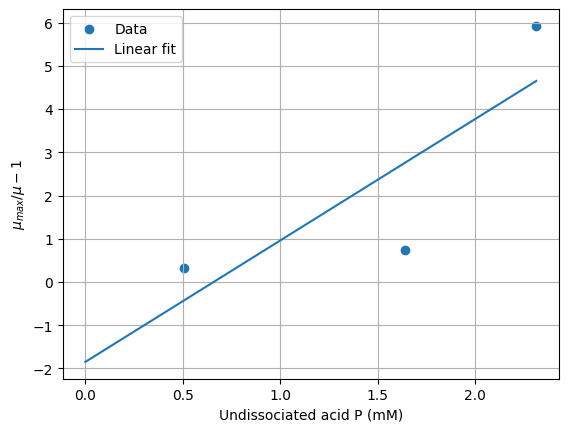

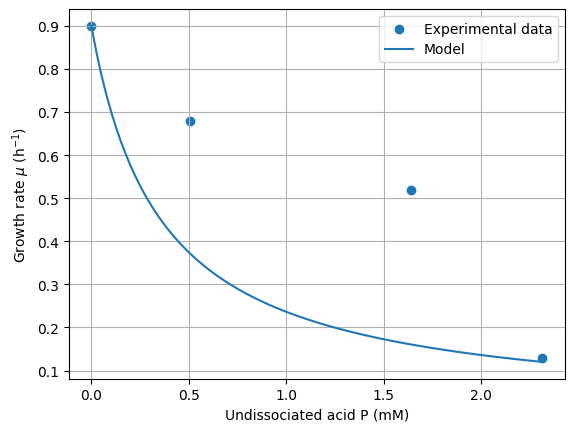

In [ ]:
p_gL = np.array([0, 12, 39, 55])  #g/L
mu = np.array([0.9, 0.68, 0.52, 0.13])


pH = 6.3
pKa = 3.88
M = 90.08   # g/mol


p_total_mM = (p_gL / M) * 1000


fraction = 1 / (1 + 10**(pH - pKa))


P = p_total_mM * fraction


mu_max = mu[0]

P_fit = P[1:]
mu_fit = mu[1:]


y = (mu_max / mu_fit) - 1


coeffs = np.polyfit(P_fit, y, 1)
slope = coeffs[0]
intercept = coeffs[1]


K_I = 1 / slope

print(f"Undissociated fraction = {fraction:.6f}")
print(f"P values (mM) = {P}")
print(f"K_I = {K_I:.3f} mM")


P_line = np.linspace(0, max(P), 100)
y_line = slope * P_line + intercept

plt.figure()
plt.scatter(P_fit, y, label="Data")
plt.plot(P_line, y_line, label="Linear fit")
plt.xlabel("Undissociated acid P (mM)")
plt.ylabel(r"$\mu_{max}/\mu - 1$")
plt.legend()
plt.grid()
plt.show()


P_model = np.linspace(0, max(P), 200)
mu_model = mu_max / (1 + P_model / K_I)

plt.figure()
plt.scatter(P, mu, label="Experimental data")
plt.plot(P_model, mu_model, label="Model")
plt.xlabel("Undissociated acid P (mM)")
plt.ylabel(r"Growth rate $\mu$ (h$^{-1}$)")
plt.legend()
plt.grid()
plt.show()

**Results and Interpretation (b)**

*Linearization and estimation of ($K_I$)*

The linearized form of the model was used to estimate the inhibition constant ($K_I$) by plotting
$$
\frac{\mu_{\max}}{\mu} - 1 \quad \text{as a function of} \quad P
$$

A linear regression was performed on the transformed data. Although a positive trend is observed, the data points exhibit significant deviation from a straight line, particularly at intermediate concentrations of (P). This indicates that the linear relationship predicted by the model is only approximately satisfied.

As a result, the estimation of ($K_I$) is subject to uncertainty, since the slope is influenced by the scatter in the data. The linearization therefore provides only an approximate value of the inhibition constant.

*Model fit compared to experimental data*

The fitted model was then evaluated by comparing the predicted growth rates to the experimental data.

The model captures the overall decreasing trend of the growth rate with increasing undissociated acid concentration (P), confirming that the inhibition effect is qualitatively well described. However, clear discrepancies are observed between the model and the data.

In particular, for intermediate values of (P) (approximately 10–40 mM), the model significantly underestimates the growth rate. This suggests that the model overpredicts the strength of inhibition in this concentration range. At higher concentrations, the agreement improves, with the model approaching the experimental values more closely.

These deviations indicate that, while the model reproduces the general behavior of the system, it does not fully capture the underlying kinetics across the entire range of concentrations. This suggests that the inhibition mechanism may be more complex than assumed, or that the model parameters estimated through linearization are affected by the scatter in the transformed data.

The inhibition constant obtained from the linearized fit is
$$
K_I = 0.356 \ \text{mM}
$$

This means that, according to the model, an undissociated lactic acid concentration of about $8.5$ mM would reduce the growth rate to half of $\mu_{\max}$. The value indicates a relatively strong sensitivity of the microorganism to the inhibitor. However, since the linearized plot showed significant scatter, this estimate should be considered approximate rather than exact.

***c)***
The preivously stated assumptions still apply in this question. 

**Methodology**

The second inhibition model is given by

$$
\mu = \mu_{\max}\left(1 - \frac{P}{P_{\max}}\right)
$$

where $P_{\max}$ is the characteristic model parameter. It corresponds to the inhibitor concentration for which the predicted growth rate becomes zero.
Since $\mu_{\max}$ is known from the experimental point at $P=0$, the only unknown parameter is $P_{\max}$. Rearranging the model gives:

$$
\frac{\mu}{\mu_{\max}} = 1 - \frac{P}{P_{\max}}
$$

and therefore

$$
1 - \frac{\mu}{\mu_{\max}} = \frac{P}{P_{\max}}
$$

This can be written in linear form as

$$
y = aP
$$

with

$$
y = 1 - \frac{\mu}{\mu_{\max}}
\qquad \text{and} \qquad
a = \frac{1}{P_{\max}}
$$

A linear regression is performed on the transformed data to estimate the slope, from which the parameter is obtained as

$$
P_{\max} = \frac{1}{\text{slope}}
$$

Once $P_{\max}$ is determined, the model is evaluated over the experimental range of $P$ and plotted together with the model from part (b) and the experimental data.

To determine which model better describes the inhibition kinetics, the goodness of fit of both models is compared quantitatively using an error criterion such as the residual sum of squares (RSS) or the root mean square error (RMSE). The model with the lower error is considered to provide the better description of the data.

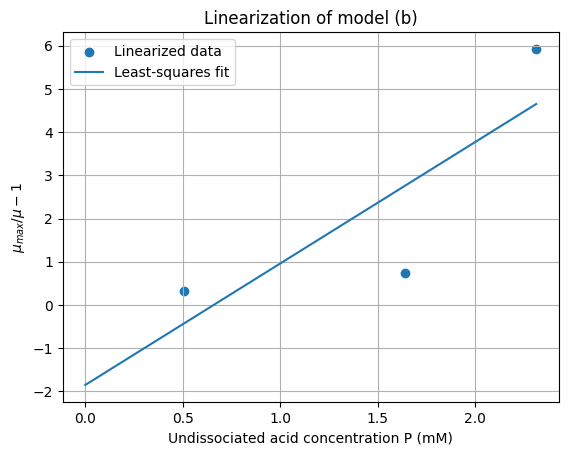

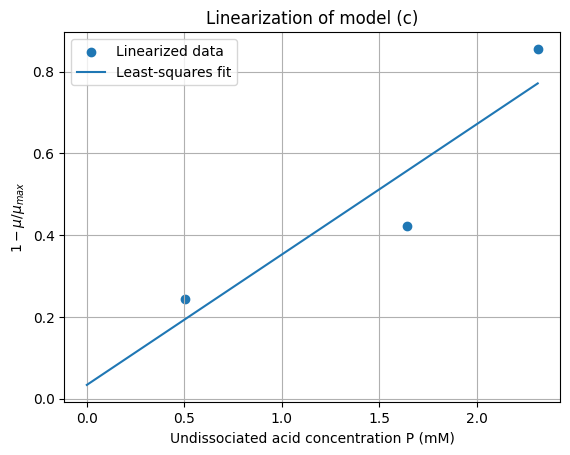

Undissociated fraction = 0.003787
P values (mM) = [0.         0.50455075 1.63978994 2.31252428]
K_I = 0.356 mM
P_max = 3.135 mM
RSS for model (b) = 0.22408
RSS for model (c) = 0.02514


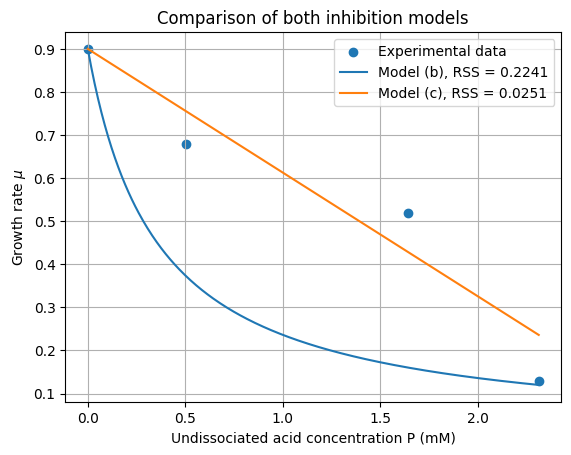

In [ ]:
p_gL = np.array([0, 12, 39, 55])        
mu = np.array([0.9, 0.68, 0.52, 0.13])   


pH = 6.3
pKa = 3.88
M = 90.08   # g/mol

p_total_mM = (p_gL / M) * 1000
fraction = 1 / (1 + 10**(pH - pKa))
P = p_total_mM * fraction


mu_max = mu[0]

P_fit = P[1:]
mu_fit = mu[1:]

y_b = (mu_max / mu_fit) - 1
slope_b, intercept_b = np.polyfit(P_fit, y_b, 1)
K_I = 1 / slope_b


P_line = np.linspace(0, max(P), 200)
y_b_line = slope_b * P_line + intercept_b

plt.figure()
plt.scatter(P_fit, y_b, label="Linearized data")
plt.plot(P_line, y_b_line, label="Least-squares fit")
plt.xlabel("Undissociated acid concentration P (mM)")
plt.ylabel(r"$\mu_{max}/\mu - 1$")
plt.title("Linearization of model (b)")
plt.legend()
plt.grid()
plt.show()


y_c = 1 - (mu_fit / mu_max)
slope_c, intercept_c = np.polyfit(P_fit, y_c, 1)
P_max = 1 / slope_c


y_c_line = slope_c * P_line + intercept_c

plt.figure()
plt.scatter(P_fit, y_c, label="Linearized data")
plt.plot(P_line, y_c_line, label="Least-squares fit")
plt.xlabel("Undissociated acid concentration P (mM)")
plt.ylabel(r"$1 - \mu/\mu_{max}$")
plt.title("Linearization of model (c)")
plt.legend()
plt.grid()
plt.show()

P_model = np.linspace(0, max(P), 400)


mu_model_b = mu_max / (1 + P_model / K_I)


mu_model_c = mu_max * (1 - P_model / P_max)
mu_model_c = np.maximum(mu_model_c, 0)   


mu_pred_b = mu_max / (1 + P / K_I)
mu_pred_c = mu_max * (1 - P / P_max)
mu_pred_c = np.maximum(mu_pred_c, 0)

RSS_b = np.sum((mu - mu_pred_b)**2)
RSS_c = np.sum((mu - mu_pred_c)**2)

print(f"Undissociated fraction = {fraction:.6f}")
print(f"P values (mM) = {P}")
print(f"K_I = {K_I:.3f} mM")
print(f"P_max = {P_max:.3f} mM")
print(f"RSS for model (b) = {RSS_b:.5f}")
print(f"RSS for model (c) = {RSS_c:.5f}")

plt.figure()
plt.scatter(P, mu, label="Experimental data")
plt.plot(P_model, mu_model_b, label=f"Model (b), RSS = {RSS_b:.4f}")
plt.plot(P_model, mu_model_c, label=f"Model (c), RSS = {RSS_c:.4f}")
plt.xlabel("Undissociated acid concentration P (mM)")
plt.ylabel(r"Growth rate $\mu$")
plt.title("Comparison of both inhibition models")
plt.legend()
plt.grid()
plt.show()

 **Comparison of the two models**

The experimental data were compared with the two inhibition models using a least-squares criterion. In this approach, the parameters of each model are determined by minimizing the sum of the squared differences between the experimental values and the model predictions:

$$
\text{RSS} = \sum (\mu_{\text{exp}} - \mu_{\text{model}})^2
$$

A lower value of the residual sum of squares (RSS) therefore indicates a better agreement between the model and the experimental data.

For the present data, the following values were obtained:

$$
\text{RSS}*{(b)} = 0.2241 \quad \text{and} \quad \text{RSS}*{(c)} = 0.0251
$$

This shows that model (c) provides a significantly better fit to the experimental data than model (b).
Model (b) assumes a hyperbolic dependence of the growth rate on the inhibitor concentration:

$$
\mu = \mu_{\max} \cdot \frac{1}{1 + \frac{P}{K_I}}
$$

This form predicts a strong curvature, with a rapid decrease in growth rate at low concentrations of $P$. However, the experimental data show a more gradual and approximately linear decrease over the investigated range. As a result, model (b) underestimates the growth rate at intermediate concentrations and deviates significantly from the data.

In contrast, model (c) assumes a linear dependence:

$$
\mu = \mu_{\max} \left(1 - \frac{P}{P_{\max}}\right)
$$

This simpler form better captures the observed trend, as the decrease in growth rate appears approximately linear over the range of measured concentrations. Consequently, model (c) remains closer to the experimental points across the entire domain, leading to a significantly lower residual error.

***d)***
Again the same assumption were used as the preuvous questions.

**Methodology**

For each total lactic acid concentration, the total concentration is first converted from g/L to mM:

$$
P_{\text{total}} = \frac{p}{M}\times 1000
$$
with (M = 90.08\ \text{g/mol}).
Since lactic acid is a weak acid, only a fraction of the total acid is present in the undissociated form. At a given pH, this fraction is:

$$
\frac{1}{1+10^{\text{pH}-\text{p}K_a}}
$$
with (\text{p}K_a = 3.88).
The concentration of undissociated acid is therefore:
$$
P = P_{\text{total}} \cdot \frac{1}{1+10^{\text{pH}-\text{p}K_a}}
$$

This value is then introduced into the inhibition model from part (c):

$$
\mu = \mu_{\max}\left(1-\frac{P}{P_{\max}}\right)
$$

To facilitate comparison, the **relative specific growth rate** is plotted as a function of pH:

$$
\frac{\mu}{\mu_{\max}} = 1-\frac{P}{P_{\max}}
$$

for both $1\ \text{g/L}$ and $10\ \text{g/L}$ total lactic acid.

The pH at which growth stops is obtained by setting:

$$
\mu = 0
$$

which gives:

$$
P = P_{\max}
$$

Using the expression for the undissociated acid concentration, the stopping pH is therefore found by solving:

$$
P_{\max} = P_{\text{total}} \cdot \frac{1}{1+10^{\text{pH}-\text{p}K_a}}
$$

for each total lactic acid concentration.
The relative growth rate is computed over a pH range of 2.0 to 8.0 for two total lactic acid concentrations: 1 g/L and 10 g/L. Negative values are clipped to zero since growth cannot be negative.



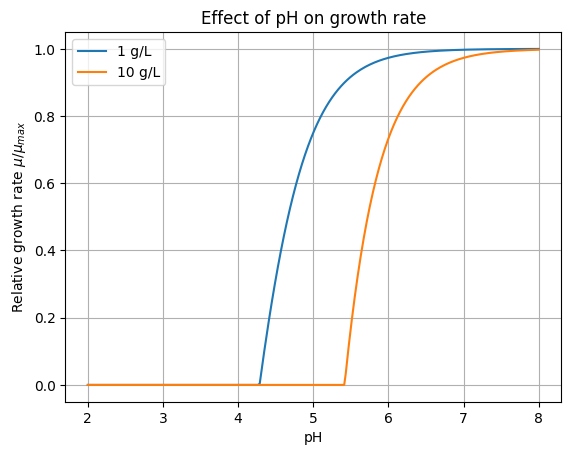

In [ ]:
pKa = 3.88
M = 90.08  # g/mol

P_max = 3.135 

p_values = [1, 10]
p_total_mM = [(p / M) * 1000 for p in p_values]
pH = np.linspace(2, 8, 300)
plt.figure()

for p_tot, label in zip(p_total_mM, ["1 g/L", "10 g/L"]):
    fraction = 1 / (1 + 10**(pH - pKa))
    P = p_tot * fraction
    mu_rel = 1 - P / P_max
    
    
    mu_rel = np.maximum(mu_rel, 0)
    
    plt.plot(pH, mu_rel, label=label)

plt.xlabel("pH")
plt.ylabel(r"Relative growth rate $\mu / \mu_{max}$")
plt.title("Effect of pH on growth rate")
plt.legend()
plt.grid()

plt.show()

**Interpretation of results**

The plot shows the variation of the relative growth rate $\mu / \mu_{\max}$ as a function of pH for two total lactic acid concentrations (1 g/L and 10 g/L).

In both cases, the growth rate increases with increasing pH. This behavior is consistent with the acid–base equilibrium of lactic acid: at low pH, a larger fraction of the acid is in the undissociated form (HA), which is responsible for inhibition. As the pH increases, the fraction of undissociated acid decreases, leading to a reduction in inhibition and a recovery of growth.

A strong difference is observed between the two concentrations. For 10 g/L, the growth rate is zero over a wide range of low pH values, indicating complete inhibition. Growth only resumes above a threshold pH of approximately 5.4–5.5. In contrast, for 1 g/L, the inhibition is less severe, and growth resumes at a lower pH (around 4.2–4.3).

This difference can be explained by the higher total acid concentration in the 10 g/L case, which leads to a larger amount of undissociated acid at any given pH. As a result, stronger inhibition occurs and a higher pH is required to reduce the undissociated fraction below the critical value $P_{\max}$.
The plateau is reached earlier for 1 g/L than for 10 g/L. This indicates that at lower total acid concentration, the inhibitory effect becomes negligible at a lower pH, whereas for 10 g/L a higher pH is required before the same recovery is achieved.

Overall, the results show that both pH and total lactic acid concentration strongly influence microbial growth, with lower pH and higher acid concentrations leading to increased inhibition.

# Exercise 3 - Enzyme reactions

***a)***

Reaction mechanism:
$$
\
E + S \xrightleftharpoons[k_{1,b}]{k_{1,f}} ES 
\xrightleftharpoons[k_{2,b}]{k_{2,f}} E + P
\
$$

Elementary reaction rates:
$$
\
r_{1,f} = k_{1,f}[E][S], \quad
r_{1,b} = k_{1,b}[ES]
\
$$
$$
\
r_{2,f} = k_{2,f}[ES], \quad
r_{2,b} = k_{2,b}[E][P]
\
$$

For species $i$:
$$
\frac{dN_i}{dt} = V \sum_j \nu_{ij} r_j
$$


Since $C_i = N_i/V$ and $V = \text{constant}$:
So we have :

$$
\frac{dC_i}{dt} = \frac{1}{V}\frac{dN_i}{dt}
$$
Substrate:
$$
\frac{d[S]}{dt}
= -k_{1,f}[E][S] + k_{1,b}[ES]
$$
Product:
$$
\frac{d[P]}{dt}
= k_{2,f}[ES] - k_{2,b}[E][P]
$$
Complex:
$$
\frac{d[ES]}{dt}
= k_{1,f}[E][S] - k_{1,b}[ES]
- k_{2,f}[ES] + k_{2,b}[E][P]
$$
Free enzyme:
$$
\frac{d[E]}{dt}
= -k_{1,f}[E][S] + k_{1,b}[ES]
+ k_{2,f}[ES] - k_{2,b}[E][P]
$$

Furthermore the total enzyme is constant:
$$
[E] + [ES] = [E]_0 = \text{constant}
$$
Substrate moiety is conserved:
$$
[S] + [P] + [ES] = [S]_0 = \text{constant}
$$

***b)***

We assume the enzyme complex is time-invariant:

$$
\frac{d[ES]}{dt} = 0
$$

Mass balance for $ES$:

$$
\frac{d[ES]}{dt}
=
k_{1,f}[E][S]
- k_{1,b}[ES]
- k_{2,f}[ES]
+ k_{2,b}[E][P]
= 0
$$

Substitute $[E] = [E]_0 - [ES]$:

$$
k_{1,f}([E]_0 - [ES])[S]
+ k_{2,b}([E]_0 - [ES])[P]
=
(k_{1,b} + k_{2,f})[ES]
$$

Expand:

$$
k_{1,f}[E]_0[S] + k_{2,b}[E]_0[P]
-
(k_{1,f}[S] + k_{2,b}[P])[ES]
=
(k_{1,b} + k_{2,f})[ES]
$$

Rearrange:

$$
k_{1,f}[E]_0[S] + k_{2,b}[E]_0[P]
=
\left(k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]\right)[ES]
$$

***Expression for the complex concentration***

$$
[ES]
=
\frac{[E]_0\left(k_{1,f}[S] + k_{2,b}[P]\right)}
{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}
$$

***Rate of product formation***

$$
\frac{d[P]}{dt}
=
k_{2,f}[ES]
-
k_{2,b}[E][P]
$$

Substitute $[E] = [E]_0 - [ES]$:

$$
\frac{d[P]}{dt}
=
k_{2,f}[ES]
-
k_{2,b}([E]_0 - [ES])[P]
$$

$$
\frac{d[P]}{dt}
=
\left(k_{2,f} + k_{2,b}[P]\right)[ES]
-
k_{2,b}[E]_0[P]
$$

Insert the QSSA expression for $[ES]$:

$$
\frac{d[P]}{dt}
=
\left(k_{2,f} + k_{2,b}[P]\right)
\frac{[E]_0\left(k_{1,f}[S] + k_{2,b}[P]\right)}
{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}
-
k_{2,b}[E]_0[P]
$$

Simplifying:
$$
\boxed{
\frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}
}
$$

***c)***

From part (b), the rate of product formation was
$$
\frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S]-k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$

We identify the reaction rate as

$$
v([S],[P])=\frac{d[P]}{dt}
$$

and divide numerator and denominator by $k_{1,b}+k_{2,f}$:

$$
v([S],[P])
=
\frac{
\displaystyle
\frac{[E]_0k_{1,f}k_{2,f}}{k_{1,b}+k_{2,f}}[S]
-
\frac{[E]_0k_{1,b}k_{2,b}}{k_{1,b}+k_{2,f}}[P]
}{
\displaystyle
1+\frac{k_{1,f}}{k_{1,b}+k_{2,f}}[S]
+\frac{k_{2,b}}{k_{1,b}+k_{2,f}}[P]
}
$$

This has the same form as

$$
v([S],[P])
=
\frac{
\displaystyle
\frac{V_{\max,f}[S]}{K_{m,S}}
-
\frac{V_{\max,b}[P]}{K_{m,P}}
}{
\displaystyle
1+\frac{[S]}{K_{m,S}}+\frac{[P]}{K_{m,P}}
}
$$

By comparison, the lumped parameters are

$$
K_{m,S}=\frac{k_{1,b}+k_{2,f}}{k_{1,f}}
$$

$$
K_{m,P}=\frac{k_{1,b}+k_{2,f}}{k_{2,b}}
$$

$$
V_{\max,f}=[E]_0\,k_{2,f}
$$

$$
V_{\max,b}=[E]_0\,k_{1,b}
$$

***Elementary rate constants be determined***

Not from $V_{\max,f}$, $V_{\max,b}$, $K_{m,S}$, and $K_{m,P}$ **alone**, because these parameters depend on the additional quantity $[E]_0$.

So, to recover all four elementary rate constants $k_{1,f}, k_{1,b}, k_{2,f}, k_{2,b}$, we also need an *independent measurement of the total enzyme concentration* (or active enzyme concentration) $[E]_0$.

If $[E]_0$ is known, then the elementary rate constants can be obtained as

$$
k_{2,f}=\frac{V_{\max,f}}{[E]_0}
$$

$$
k_{1,b}=\frac{V_{\max,b}}{[E]_0}
$$

$$
k_{1,f}=\frac{k_{1,b}+k_{2,f}}{K_{m,S}}
$$

$$
k_{2,b}=\frac{k_{1,b}+k_{2,f}}{K_{m,P}}
$$

Substituting for $k_{1,b}$ and $k_{2,f}$:

$$
k_{1,f}
=
\frac{V_{\max,b}+V_{\max,f}}{[E]_0K_{m,S}}
$$

$$
k_{2,b}
=
\frac{V_{\max,b}+V_{\max,f}}{[E]_0K_{m,P}}
$$

***Required aditionnal data***
To determine all elementary rate constants, the required additional data is:

$$
{\text{the total active enzyme concentration } [E]_0}
$$

Without $[E]_0$, only the lumped kinetic parameters can be identified, not the individual elementary rate constants.

***d)***

Kinetic constants:

$$
k_{1,b} = 10\ \mathrm{s^{-1}}, \qquad
k_{2,f} = 22\ \mathrm{s^{-1}}
$$

Michaelis constants:

$$
K_{m,S} = 210\ \mu\mathrm{M}, \qquad
K_{m,P} = 97\ \mu\mathrm{M}
$$

Convert to SI units:

$$
K_{m,S} = 210 \times 10^{-6}\ \mathrm{mol\,L^{-1}}, \qquad
K_{m,P} = 97 \times 10^{-6}\ \mathrm{mol\,L^{-1}}
$$

Initial concentrations:

$$
[S]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[P]_0 = 0, \qquad
[E]_0 = 0.1\ \mathrm{mol\,L^{-1}}
$$

Time interval:

$$
t \in [0, 5]\ \mathrm{s}
$$

***QSSA expression for the enzyme complex***

From part (b):

$$
[ES] =
\frac{[E]_0 \left(k_{1,f}[S] + k_{2,b}[P]\right)}
{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}
$$

and

$$
[E] = [E]_0 - [ES]
$$

***Reduced mass balances***

Using the QSSA approximation:

$$
\frac{d[S]}{dt}
=
- k_{1,f}[E][S] + k_{1,b}[ES]
$$

$$
\frac{d[P]}{dt}
=
k_{2,f}[ES] - k_{2,b}[E][P]
$$

with the expressions for $[ES]$ and $[E]$ above.

Equivalently, single reduced equations for the product and substrate are: 

$$
\frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b} + k_{2,f} + k_{1,f}[S] + k_{2,b}[P]}
$$

$$
\frac{d[S]}{dt}
=
-k_{1,f}[S]
\left(
[E]_0 -
\frac{[E]_0\left(k_{1,f}[S] + k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
\right)
+
k_{1,b}
\frac{[E]_0\left(k_{1,f}[S] + k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


k1b = 10.0              # s^-1
k2f = 22.0              # s^-1
KmS = 210e-6            # mol/L
KmP = 97e-6             # mol/L


S0 = 1.0                # mol/L
P0 = 0.0                # mol/L
E0 = 0.1                # mol/L


k1f = (k1b + k2f) / KmS     # L mol^-1 s^-1
k2b = (k1b + k2f) / KmP     # L mol^-1 s^-1


def ES_qssa(S, P):
    return E0 * (k1f*S + k2b*P) / (k1b + k2f + k1f*S + k2b*P)


def rhs(t, y):
    S, P = y
    ES = ES_qssa(S, P)
    E = E0 - ES

    dSdt = -k1f * E * S + k1b * ES
    dPdt =  k2f * ES - k2b * E * P

    return [dSdt, dPdt]


t_span = (0.0, 5.0)
t_eval = np.linspace(0.0, 5.0, 500)

sol = solve_ivp(rhs, t_span, [S0, P0], t_eval=t_eval, method="LSODA")

t = sol.t
S = sol.y[0]
P = sol.y[1]
ES = ES_qssa(S, P)
E = E0 - ES


print("Elementary rate constants:")
print(f"k1f = {k1f:.6e} L mol^-1 s^-1")
print(f"k1b = {k1b:.6e} s^-1")
print(f"k2f = {k2f:.6e} s^-1")
print(f"k2b = {k2b:.6e} L mol^-1 s^-1")
print()

print("Final concentrations at t = 5 s:")
print(f"  = {S[-1]:.6f} mol/L")
print(f"  = {P[-1]:.6f} mol/L")
print(f" = {ES[-1]:.6f} mol/L")
print(f"  = {E[-1]:.6f} mol/L")


times_to_report = [0.0, 0.5, 1.0, 2.0, 5.0]
print("\nSelected values:")
for time_point in times_to_report:
    idx = np.argmin(np.abs(t - time_point))
    print(f"t = {t[idx]:>4.1f} s : [S] = {S[idx]:.6f} mol/L, [P] = {P[idx]:.6f} mol/L")

plt.figure(figsize=(8, 5))
plt.plot(t, S, label='[S] (substrate)')
plt.plot(t, P, label='[P] (product)')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Part (d): Reversible Michaelis-Menten kinetics with QSSA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

***Methodology***

The system was modeled using mass balances derived from the reaction mechanism.  
The Quasi-Steady-State Assumption (QSSA) was applied to eliminate the intermediate complex $[ES]$, reducing the model to a nonlinear ODE system in $[S]$ and $[P]$.  
The equations were solved numerically over the interval $0$–$5$ s using the specified initial conditions.

Assumptions:

- Constant reactor volume  
- Closed system  
- Total enzyme concentration constant  
- QSSA valid for the enzyme–substrate complex  

***Interpretation of results***

The product concentration increases rapidly at early times while the substrate concentration decreases correspondingly. As product accumulates, the reverse reaction becomes significant, causing the net rate to decline.

Because the reaction is reversible, the system approaches an equilibrium state rather than complete conversion. The final concentrations are close to a 1:1 distribution between substrate and product, indicating comparable forward and backward driving forces under the given conditions.


***e)***

In this case, the initial conditions are

$$
[S]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[P]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[E]_0 = 0.1\ \mathrm{mol\,L^{-1}}
$$

The reduced reversible Michaelis--Menten rate equation derived in part (b) is

$$
\frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$

Using the constants from part (d),

$$
k_{1,b} = 10\ \mathrm{s^{-1}}, \qquad
k_{2,f} = 22\ \mathrm{s^{-1}}
$$

$$
k_{1,f} = 1.52\times 10^{5}\ \mathrm{L\,mol^{-1}\,s^{-1}}, \qquad
k_{2,b} = 3.30\times 10^{5}\ \mathrm{L\,mol^{-1}\,s^{-1}}
$$

the ODE system was solved on the interval

$$
t \in [0,5]\ \mathrm{s}
$$

with the QSSA approximation for $[ES]$.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

k1b = 10.0                     # s^-1
k2f = 22.0                     # s^-1
KmS = 210e-6                   # mol/L
KmP = 97e-6                    # mol/L

# From part (d)
k1f = (k1b + k2f) / KmS        # L mol^-1 s^-1
k2b = (k1b + k2f) / KmP        # L mol^-1 s^-1

E0 = 0.1                       # mol/L
S0 = 1.0                       # mol/L
P0 = 1.0                       # mol/L

def ES_qssa(S, P):
    return E0 * (k1f*S + k2b*P) / (k1b + k2f + k1f*S + k2b*P)

def rhs(t, y):
    S, P = y
    ES = ES_qssa(S, P)
    E = E0 - ES

    dSdt = -k1f*E*S + k1b*ES
    dPdt =  k2f*ES - k2b*E*P

    return [dSdt, dPdt]


t_span = (0.0, 5.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

sol = solve_ivp(rhs, t_span, [S0, P0], t_eval=t_eval, method="LSODA")

S = sol.y[0]
P = sol.y[1]
ES = ES_qssa(S, P)
E = E0 - ES


print("Elementary rate constants:")
print(f"k1f = {k1f:.4e} L mol^-1 s^-1")
print(f"k1b = {k1b:.4e} s^-1")
print(f"k2f = {k2f:.4e} s^-1")
print(f"k2b = {k2b:.4e} L mol^-1 s^-1")
print()

print("Final concentrations at t = 5 s:")
print(f"  = {S[-1]:.6f} mol/L")
print(f"  = {P[-1]:.6f} mol/L")
print(f" = {ES[-1]:.6f} mol/L")
print(f"  = {E[-1]:.6f} mol/L")


v0 = (E0 * (k1f*k2f*S0 - k1b*k2b*P0)) / (k1b + k2f + k1f*S0 + k2b*P0)
print()
print(f"Initial net rate v(0) = d[P]/dt|_(t=0) = {v0:.6f} mol L^-1 s^-1")

plt.figure(figsize=(8, 5))
plt.plot(sol.t, S, label='[S] (substrate)')
plt.plot(sol.t, P, label='[P] (product)')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Reversible Michaelis-Menten kinetics with [S]0=1, [P]0=1, [E]0=0.1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In part (e), the initial conditions are

$$
[S]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[P]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[E]_0 = 0.1\ \mathrm{mol\,L^{-1}}.
$$

The plot shows that the substrate concentration decreases only slightly, from about

$$
=1.000\ \mathrm{mol\,L^{-1}}
$$

to approximately

$$
\approx 0.992\ \mathrm{mol\,L^{-1}},
$$

while the product concentration increases only slightly, from

$$
=1.000\ \mathrm{mol\,L^{-1}}
$$

to approximately

$$
\approx 1.008\ \mathrm{mol\,L^{-1}}.
$$

Thus, the net reaction is still in the forward direction, since $[P]$ increases and $[S]$ decreases, but the rate is very small. The curves are nearly flat, which indicates that the system is already close to equilibrium at the initial time.

This behavior follows directly from the reversible Michaelis--Menten rate law:

$$
v([S],[P]) = \frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S]-k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}.
$$

Because $[P]_0$ is already large, the backward contribution

$$
k_{1,b}k_{2,b}[P]
$$

is significant from the start. As a result, the numerator is much smaller than in part (d), so the net forward rate is strongly reduced.

In addition, $[P]$ also appears in the denominator:

$$
k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P],
$$

which further lowers the rate. Therefore, the product concentration slows the reaction in two ways:

- it subtracts from the forward driving force in the numerator,
- it increases the denominator.

This is why, in part (e), only a very small conversion of substrate into product is observed over the interval $0$--$5\ \mathrm{s}$.

*Comparison between part (d) and part (e)*  

In part (d), the initial product concentration was zero:

$$
[S]_0 = 1,\qquad [P]_0 = 0.
$$

The corresponding plot shows a rapid decrease of substrate from about $1$ to $0.5\ \mathrm{mol\,L^{-1}}$, while the product concentration increases from $0$ to about $0.5\ \mathrm{mol\,L^{-1}}$. The system evolves quickly toward an equilibrium state near

$$
[S]\approx [P]\approx 0.5\ \mathrm{mol\,L^{-1}}.
$$

In part (e), however, the system starts with

$$
[S]_0 = 1,\qquad [P]_0 = 1.
$$

Compared with part (d), the changes are much smaller: the substrate decreases only slightly and the product increases only slightly. Hence, the reaction is much slower in net forward direction.

The difference between the two plots can be explained by the initial amount of product:

- In **part (d)**, since $[P]_0=0$, there is initially no backward contribution from product, so the forward reaction dominates strongly.
- In **part (e)**, since $[P]_0=1$, the backward term is already important at $t=0$, so the net rate is much smaller.

Therefore, both plots show approach toward equilibrium, but they start from different positions relative to equilibrium:

- **Part (d):** the system starts far from equilibrium, so the concentrations change rapidly.
- **Part (e):** the system starts much closer to equilibrium, so the concentrations change only slightly.

*Conclusion*

The second plot in part (e) shows that the reaction still proceeds slightly in the forward direction, but much more slowly than in part (d). Compared with part (d), the presence of initial product strongly suppresses the net formation of more product. This occurs because product appears explicitly in the reversible rate equation and opposes the forward reaction. As a result, part (e) starts much closer to equilibrium than part (d), and the concentration changes are therefore much smaller.

***Comparison with Project 1 - Exercise 1***

For this case, the initial conditions are

$$
[S]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[P]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[E]_0 = 0.1\ \mathrm{mol\,L^{-1}}
$$

The reversible rate equation obtained in parts (b)--(d) is

$$
v([S],[P]) = \frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$

This must be compared with the rate equation from **Project 1 -- Exercise 1**, which was the irreversible Michaelis--Menten form:

$$
v = \frac{v_{\max}[S]}{K_M + [S]}
$$

*Main difference between the two rate equations*

The rate law from Project 1 depends only on the substrate concentration:

$$
v = \frac{v_{\max}[S]}{K_M + [S]}
$$

Therefore, in the irreversible model:

- the rate is always nonnegative,
- product concentration does not appear in the rate law,
- increasing $[S]$ always increases the reaction rate,
- the reaction only proceeds in the forward direction.

By contrast, the reversible rate law from Project 2 is

$$
v([S],[P])
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$

which depends on **both** $[S]$ and $[P]$.

Thus, unlike the Project 1 model, the rate is determined by the competition between:

- the forward term

$$
k_{1,f}k_{2,f}[S]
$$

and

- the backward term

$$
k_{1,b}k_{2,b}[P].
$$

*Effect of product concentration on the rate equation*

The product concentration affects the rate equation in two ways.

    1. In the numerator

The numerator is

$$
[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right).
$$

The term

$$
-k_{1,b}k_{2,b}[P]
$$

reduces the net forward rate. Therefore, increasing $[P]$ decreases the rate of product formation.

If the product term becomes large enough, then

$$
k_{1,b}k_{2,b}[P] > k_{1,f}k_{2,f}[S],
$$

and the net rate becomes negative:

$$
\frac{d[P]}{dt} < 0.
$$

In that case, the reaction runs backward and product is converted back into substrate.

    2. In the denominator

The denominator is

$$
k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P].
$$

So increasing $[P]$ also increases the denominator, which further decreases the magnitude of the forward rate.

Hence, product slows the reaction both by:

- subtracting from the driving force in the numerator,
- increasing the denominator.

*Interpretation for this simulation*

For the initial conditions

$$
[S]_0 = 1,\qquad [P]_0 = 1,
$$

the simulation shows that $[P]$ increases only slightly and $[S]$ decreases only slightly. This means the net forward rate is much smaller than in part (d), where $[P]_0 = 0$.

This behavior is explained directly by the reversible rate law: because product is already present initially, the backward term

$$
k_{1,b}k_{2,b}[P]
$$

is already significant at $t=0$, so the net rate is reduced.

In Project 1, this effect could not occur, because the irreversible rate law contains no product term.

*Which parameter should be changed to make this mechanism similar to Project 1 - Exercise 1?*

To recover behavior similar to the Project 1 mechanism, the reverse product-binding step must be removed. This means setting

$$
k_{2,b} = 0.
$$

Then the reversible mechanism

$$
E + S \xrightleftharpoons[k_{1,b}]{k_{1,f}} ES
\xrightleftharpoons[k_{2,b}]{k_{2,f}} E + P
$$

reduces to the irreversible mechanism

$$
E + S \xrightleftharpoons[k_{1,b}]{k_{1,f}} ES
\xrightarrow{k_{2,f}} E + P.
$$

In that case, the rate law no longer depends on $[P]$, and it becomes analogous to the original Michaelis--Menten expression from Project 1.

Therefore, the key parameter responsible for the difference between the two models is

$$
\boxed{k_{2,b}}
$$

because it introduces reversibility and makes the product concentration appear in the rate equation.

*Conclusion*

Compared with Project 1, the rate law in this project is fundamentally different because it includes reversibility. The Project 1 rate depends only on substrate concentration, while the present rate depends on both substrate and product concentration. As a result, product accumulation reduces the net forward rate and can even reverse the reaction. To make the present mechanism similar to the irreversible Michaelis--Menten model of Project 1, the backward rate constant for the product step must be set to zero:

$$
\boxed{k_{2,b}=0}
$$

***e)***

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

k1b = 10.0              # s^-1
k2f = 22.0              # s^-1
KmS = 210e-6            # mol/L
KmP = 97e-6             # mol/L


k1f = (k1b + k2f) / KmS     # L mol^-1 s^-1
k2b = (k1b + k2f) / KmP     # L mol^-1 s^-1


S0 = 1.0                # mol/L
P0 = 3.0                # mol/L
E0 = 0.1                # mol/L


def ES_qssa(S, P):
    return E0 * (k1f*S + k2b*P) / (k1b + k2f + k1f*S + k2b*P)

def rhs(t, y):
    S, P = y
    ES = ES_qssa(S, P)
    E = E0 - ES

    dSdt = -k1f * E * S + k1b * ES
    dPdt =  k2f * ES - k2b * E * P

    return [dSdt, dPdt]

t_span = (0.0, 5.0)
t_eval = np.linspace(0.0, 5.0, 500)

sol = solve_ivp(rhs, t_span, [S0, P0], t_eval=t_eval, method="LSODA")

t = sol.t
S = sol.y[0]
P = sol.y[1]
ES = ES_qssa(S, P)
E = E0 - ES

Keq = (k1f * k2f) / (k1b * k2b)
Q0 = P0 / S0

v0 = (E0 * (k1f*k2f*S0 - k1b*k2b*P0)) / (k1b + k2f + k1f*S0 + k2b*P0)

print("Bonus case: high initial product concentration")
print(f"k1f = {k1f:.6e} L mol^-1 s^-1")
print(f"k1b = {k1b:.6e} s^-1")
print(f"k2f = {k2f:.6e} s^-1")
print(f"k2b = {k2b:.6e} L mol^-1 s^-1")
print()
print(f"K_eq = {Keq:.6f}")
print(f"Q0    = {Q0:.6f}")
print(f"Initial net rate v(0) = {v0:.6f} mol L^-1 s^-1")
print()

print("Final concentrations at t = 5 s:")
print(f"  = {S[-1]:.6f} mol/L")
print(f"  = {P[-1]:.6f} mol/L")
print(f" = {ES[-1]:.6f} mol/L")
print(f"  = {E[-1]:.6f} mol/L")

plt.figure(figsize=(8, 5))
plt.plot(t, S, label='[S] (substrate)')
plt.plot(t, P, label='[P] (product)')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Bonus case: reversible MM kinetics with high initial product')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Consider the initial conditions

$$
[S]_0 = 1\ \mathrm{mol\,L^{-1}}, \qquad
[P]_0 = 3\ \mathrm{mol\,L^{-1}}, \qquad
[E]_0 = 0.1\ \mathrm{mol\,L^{-1}}
$$

The reversible Michaelis--Menten rate law is

$$
v([S],[P]) = \frac{d[P]}{dt}
=
\frac{[E]_0\left(k_{1,f}k_{2,f}[S] - k_{1,b}k_{2,b}[P]\right)}
{k_{1,b}+k_{2,f}+k_{1,f}[S]+k_{2,b}[P]}
$$

***Initial direction of the reaction***

At the initial time, the sign of the rate is determined by the numerator:

$$
k_{1,f}k_{2,f}[S]_0 - k_{1,b}k_{2,b}[P]_0
$$

If this quantity is positive, then

$$
\frac{d[P]}{dt} > 0
$$

and product increases.

If this quantity is negative, then

$$
\frac{d[P]}{dt} < 0
$$

and product decreases.

For equilibrium, the numerator must be zero:

$$
k_{1,f}k_{2,f}[S] = k_{1,b}k_{2,b}[P]
$$

which gives

$$
\frac{[P]}{[S]} = \frac{k_{1,f}k_{2,f}}{k_{1,b}k_{2,b}} = K_{\mathrm{eq}}
$$

Using the parameters from part (d), this equilibrium ratio is approximately

$$
K_{\mathrm{eq}} \approx 1.016
$$

So the equilibrium condition is approximately

$$
\frac{[P]}{[S]} \approx 1.016
$$

***Mass-action ratio***

The initial mass-action ratio is

$$
Q = \frac{[P]_0}{[S]_0} = \frac{3}{1} = 3
$$

Since

$$
Q > K_{\mathrm{eq}}
$$

the system initially contains **too much product** compared with equilibrium. Therefore, the reaction proceeds in the **reverse direction** in order to reduce the product concentration and increase the substrate concentration.

Thus, for this case:

$$
\frac{d[P]}{dt}\Big|_{t=0} < 0
$$

and the product concentration initially **decreases**.

***Comment on the plot***

The plot should show that:

- $[P]$ decreases with time,
- $[S]$ increases with time,
- the system approaches an equilibrium state,
- the curves level off once the ratio $[P]/[S]$ approaches the equilibrium ratio.

This is different from part (d), where product was formed because the system started with no product present. Here, the initially large amount of product drives the reaction backward.

***Interpretation based on equilibrium***

The reversible rate law naturally predicts both forward and backward net reaction depending on the relation between the mass-action ratio

$$
Q = \frac{[P]}{[S]}
$$

and the equilibrium constant

$$
K_{\mathrm{eq}} = \frac{k_{1,f}k_{2,f}}{k_{1,b}k_{2,b}}
$$

- If $Q < K_{\mathrm{eq}}$, the forward reaction dominates and $[P]$ increases.
- If $Q > K_{\mathrm{eq}}$, the backward reaction dominates and $[P]$ decreases.
- If $Q = K_{\mathrm{eq}}$, the net rate is zero.

Since in this case

$$
Q = 3 > 1.016 \approx K_{\mathrm{eq}},
$$

the net reaction is initially backward, so the product concentration decreases.

# Exercise 4 - Chemostat: Yeast Biomass Production

**Question a)**
In a chemostat at steady state, the specific growth rate $\mu$ equals the dilution rate $D$:

$$D = \mu = \mu_{\max} \frac{S}{K_s + S}$$

where:
- $\mu_{\max}$ is the maximum specific growth rate (h⁻¹)
- $K_s$ is the saturation (Monod) constant (g/L)
- $S$ is the steady-state substrate concentration (g/L)

This equation is true because at steady state, cell growth exactly compensates for dilution losses.

Taking the reciprocal of the Monod equation:

$$\frac{1}{D} = \frac{K_s}{\mu_{\max}} \cdot \frac{1}{S} + \frac{1}{\mu_{\max}}$$

Plotting $1/D$ versus $1/S$ yields a straight line with:
- slope $= K_s / \mu_{\max}$
- y-intercept $= 1 / \mu_{\max}$
- x-intercept $= -1 / K_s$

The highest dilution rate ($D = 0.84$ h⁻¹) is excluded from the fit because at this operating point, cell concentration drops sharply and residual substrate jumps, indicating washout. This means that cells can no longer grow fast enough to keep up with dilution, so they are being removed from the reactor faster than they reproduce. Including these points would therefore violate the steady-state assumption.

In [ ]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])  
X = np.array([3.2,  3.7,  4.0,  4.4,  4.75, 4.9,  4.5,  0.5])   
S = np.array([0.012,0.028,0.050,0.100,0.150,0.176,0.800,9.000])  
S0 = 10.0  

mask   = D <= 0.80
D_fit  = D[mask]
S_fit  = S[mask]

inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit

slope, intercept = np.polyfit(inv_S, inv_D, 1)

mu_max = 1.0 / intercept       
Ks     = slope * mu_max          

print("=" * 45)
print("  Monod parameter estimation (part a)")
print("=" * 45)
print(f"  Slope     (Ks / µmax) = {slope:.4f}  h·g/L")
print(f"  Intercept (1 / µmax)  = {intercept:.4f}  h")
print(f"  µmax                  = {mu_max:.4f}  h⁻¹")
print(f"  Ks                    = {Ks:.4f}  g/L")
print("=" * 45)

inv_S_line = np.linspace(0, max(inv_S) * 1.05, 300)
inv_D_line = slope * inv_S_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(inv_S, inv_D, color="steelblue", zorder=5, label="Steady-state data")
ax1.plot(inv_S_line, inv_D_line, color="tomato", label="Linear fit")

ax1.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax1.axvline(0, color="grey", linewidth=0.6, linestyle="--")

ax1.annotate(f"y-int = {intercept:.3f}\n= 1/µmax",
             xy=(0, intercept), xytext=(15, intercept + 0.5),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")
x_int = -intercept / slope          # x-intercept = −1/Ks
ax1.annotate(f"x-int = {x_int:.1f}\n= −1/Ks",
             xy=(x_int, 0), xytext=(x_int + 5, 0.8),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")

ax1.set_xlabel("1/S  (L/g)", fontsize=11)
ax1.set_ylabel("1/D  (h)", fontsize=11)
ax1.set_title("Lineweaver–Burk plot\n(double-reciprocal)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
S_range = np.linspace(0, S0, 500)
mu_monod = mu_max * S_range / (Ks + S_range)

ax2.plot(S_range, mu_monod, color="tomato", label=f"Monod fit\n(µmax={mu_max:.3f}, Ks={Ks:.4f})")
ax2.scatter(S_fit, D_fit, color="steelblue", zorder=5, label="Steady-state data (used)")
ax2.scatter(S[~mask], D[~mask], color="grey", marker="x", zorder=5, s=60, label="Washout (excluded)")

ax2.set_xlabel("S  (g/L)", fontsize=11)
ax2.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax2.set_title("Monod curve", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Exercise 4a — Monod kinetic parameters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $\mu_{\max}$ | 2.2982 | h⁻¹ |
| $K_s$ | 0.5482 | g/L |

The Lineweaver–Burk linearisation yields $\mu_{\max} = 2.2982\ \text{h}^{-1}$ and $K_s = 0.5482\ \text{g/L}$. The $\mu_{\max}$ value exceeds typical aerobic literature values for yeast growth, and $K_s$ is higher than commonly reported. This is likely attributable to the double-reciprocal transformation: taking $1/S$ compresses the high-substrate points and stretches the low-substrate points, giving disproportionate weight to the least reliable measurements (low $S$, high $1/S$). The fit is therefore dominated by the point at $S = 0.012$ g/L, which pulls the line and inflates both parameters.
 
To obtain more reliable estimates, the Monod equation is fitted directly to the $(S, D)$ data using non-linear least squares regression.
Instead of transforming the data, `scipy.optimize.curve_fit` minimises the sum of squared residuals directly in the original data space:
 
$$\min_{\mu_{\max},\, K_s} \sum_i \left( D_i - \mu_{\max} \frac{S_i}{K_s + S_i} \right)^2$$
 
This avoids any distortion introduced by the double-reciprocal transformation and gives equal statistical weight to all data points. 
 

In [ ]:
from scipy.optimize import curve_fit

def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

popt, pcov   = curve_fit(monod, S_fit, D_fit, p0=[1.0, 0.1], bounds=(0, np.inf))
mu_max_nl, Ks_nl = popt
perr             = np.sqrt(np.diag(pcov))   # 1-sigma uncertainties

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

R2_lb = r_squared(D_fit, monod(S_fit, mu_max, Ks))       # mu_max, Ks from LB cell
R2_nl = r_squared(D_fit, monod(S_fit, mu_max_nl, Ks_nl))


print("=" * 55)
print(f"{'Parameter':<15} {'Lineweaver-Burk':>18} {'Non-linear':>18}")
print("-" * 55)
print(f"{'µmax (h⁻¹)':<15} {mu_max:>18.4f} {mu_max_nl:>18.4f}")
print(f"{'Ks (g/L)':<15} {Ks:>18.4f} {Ks_nl:>18.4f}")
print(f"{'R²':<15} {R2_lb:>18.4f} {R2_nl:>18.4f}")
print("=" * 55)
print(f"\nNon-linear 1σ uncertainties:  µmax ± {perr[0]:.4f} h⁻¹  |  Ks ± {perr[1]:.4f} g/L")


S_range = np.linspace(0, S0, 500)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(S_fit,    D_fit,    color="steelblue", zorder=5, label="Steady-state data (used)")
ax.scatter(S[~mask], D[~mask], color="grey", marker="x", s=60, zorder=5, label="Washout (excluded)")
ax.plot(S_range, monod(S_range, mu_max, Ks), color="tomato", linestyle="--",
        label=f"Lineweaver–Burk  (µmax={mu_max:.3f}, Ks={Ks:.4f}, R²={R2_lb:.4f})")
ax.plot(S_range, monod(S_range, mu_max_nl, Ks_nl), color="seagreen",
        label=f"Non-linear fit     (µmax={mu_max_nl:.3f}, Ks={Ks_nl:.4f}, R²={R2_nl:.4f})")

ax.set_xlabel("S  (g/L)", fontsize=11)
ax.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax.set_title("Monod curve — linear vs non linear comparison", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We get the following results now:

| Parameter | Lineweaver–Burk | Non-linear regression |
|-----------|:--------------:|:--------------------:|
| $\mu_{\max}$ (h⁻¹) | 2.2982 | 0.9975 |
| $K_s$ (g/L) | 0.5482 | 0.1288 |
| $R^2$ | 0.3520 | 0.9304 |

The non-linear regression yields a higher $R^2$ value and parameters that are more consistent with literature values for aerobic yeast growth, confirming that the Lineweaver–Burk overestimation was an result of the double-reciprocal transformation rather than a true biological feature of the data.

The $1\sigma$ uncertainties from the covariance matrix of `curve_fit` further quantify the reliability of the non-linear estimates. However, for consistency with the methodology presented in lecture 2 of the course, the Lineweaver–Burk estimates were used in the subsequent analysis.

**Question b)**

At steady state in a chemostat, the substrate consumed goes towards two things: producing new biomass and covering the maintenance energy requirements of existing cells:
 
$$D(S_{in} - S) = \frac{\mu \cdot X}{Y_{X/S}} + m \cdot X$$
 
where:
- $Y_{X/S}$ is the true biomass yield on substrate (g biomass / g substrate)
- $m$ is the maintenance energy coefficient (g substrate / g biomass / h)
- $S_{in} - S$ is the substrate consumed (g/L)

This is also known as the Herbirt Pirt equation.
 
Since $D = \mu$ at steady state, dividing both sides by $X$ gives a linear form:
 
$$\frac{D(S_{in} - S)}{X} = \frac{1}{Y_{X/S}} \cdot D + m$$
 
Plotting $\frac{D(S_{in} - S)}{X}$ against $D$ yields a straight line where:
- slope $= 1/Y_{X/S}$
- y-intercept $= m$
 
The parameters are estimated using `numpy.polyfit` on the steady-state data points (washout point at $D = 0.84$ h⁻¹ excluded).
 

In [ ]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])
X = np.array([3.2, 3.7, 4.0, 4.4, 4.75, 4.9, 4.5, 0.5])
S = np.array([0.012, 0.028, 0.050, 0.100, 0.150, 0.176, 0.800, 9.000])

S_in = 10.0

mask = D <= 0.80
D_fit = D[mask]
X_fit = X[mask]
S_fit = S[mask]

y = D_fit * (S_in - S_fit) / X_fit

slope, intercept = np.polyfit(D_fit, y, 1)

Yxs = 1 / slope
m = intercept

print(f"slope = {slope:.4f}")
print(f"intercept = {intercept:.4f}")
print(f"Yxs = {Yxs:.4f} gX/gS")
print(f"m = {m:.4f} gS/(gX·h)")

# plot
D_line = np.linspace(0, 0.85, 200)
y_line = slope * D_line + intercept

plt.figure(figsize=(7,5))
plt.scatter(D_fit, y, label="Data")
plt.plot(D_line, y_line, label="Linear fit")
plt.xlabel("D (h$^{-1}$)")
plt.ylabel(r"$D(S_{in}-S)/X$ (h$^{-1}$)")
plt.title("Estimation of $Y_{X/S}$ and $m$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $Y_{X/S}$ | 0.5185 | g biomass / g substrate |
| $m$ | 0.0872 | g substrate / g biomass / h |
 
The estimated yield coefficient $Y_{X/S} = 0.5185\ \mathrm{g_X/g_S}$ indicates that approximately 0.52 g of biomass are produced per gram of substrate consumed. This value is lower than 1, which is expected, as part of the substrate is not converted into biomass but is instead used for energy production and cellular functions. Next, the maintenance coefficient $m = 0.0872\ \mathrm{g_S\,g_X^{-1}\,h^{-1}}$ represents the amount of substrate consumed per unit biomass and time for non-growth-related processes. These include cellular maintenance activities such as ion transport, macromolecule turnover, and metabolic regulation. The positive value of $m$ is reflected by the non-zero y-intercept of the linear fit, indicating that even at very low growth rates, substrate is still consumed. This confirms the presence of maintenance metabolism in the system.

Overall, the results are physically consistent. In fact, the yield coefficient is within a reasonable range for microbial systems, and the maintenance term highlights that not all substrate contributes directly to biomass formation, especially at low dilution rates.

**Question c)**

Ignoring maintenance, the steady-state chemostat follows Monod kinetics:

$$
D=\mu=\mu_{\max}\frac{S}{K_s+S}
$$

**Maximum dilution rate**
The maximum dilution rate is reached at washout, when the reactor substrate concentration approaches the feed substrate concentration:

$$
S \to S_{in}
$$

Therefore,

$$
D_{\max}=\mu_{\max}\frac{S_{in}}{K_s+S_{in}}
$$

Using $\mu_{\max}=2.298\ \mathrm{h^{-1}}$, $K_s=0.548\ \mathrm{g\,L^{-1}}$, and $S_{in}=10\ \mathrm{g\,L^{-1}}$:

$$
D_{\max}=2.298\frac{10}{0.548+10}=2.179\ \mathrm{h^{-1}}
$$

**Optimal dilution rate**

The cell productivity is:

$$
P_X=D\cdot X
$$

Ignoring maintenance,

$$
X=Y_{X/S}(S_{in}-S)
$$

so maximizing productivity is equivalent to maximizing:

$$
D(S_{in}-S)
$$

From the Monod relation,

$$
D=\mu_{\max}\frac{S}{K_s+S}
$$

we solve for $S$:

$$
S=\frac{DK_s}{\mu_{\max}-D}
$$

Substituting into the productivity expression and maximizing with respect to $D$ gives:

$$
D_{\mathrm{opt}}=\mu_{\max}\left(1-\sqrt{\frac{K_s}{K_s+S_{in}}}\right)
$$

Numerically:

$$
D_{\mathrm{opt}}=2.298\left(1-\sqrt{\frac{0.548}{0.548+10}}\right)=1.774\ \mathrm{h^{-1}}
$$

Thus, the theoretical values are:

$$
D_{\max}=2.179\ \mathrm{h^{-1}}
$$

$$
D_{\mathrm{opt}}=1.774\ \mathrm{h^{-1}}
$$

As expected, $D_{\mathrm{opt}} < D_{\max}$, since the maximum biomass productivity is reached before washout.

**Question d)**

Based on the results from question c), we can define the following range for the dilution rate D: 

$$
0 < D < D_{\max}
$$

Using the Monod steady-state relation,

$$
D=\mu_{\max}\frac{S}{K_s+S}
$$

the substrate concentration can be written as a function of dilution rate:

$$
S(D)=\frac{D K_s}{\mu_{\max}-D}
$$

To include maintenance energy, the steady-state substrate balance is used:

$$
D(S_{in}-S)=\frac{1}{Y_{X/S}}DX+mX
$$

Solving for the biomass concentration gives:

$$
X(D)=\frac{D(S_{in}-S)}{\frac{D}{Y_{X/S}}+m}
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


mu_max = 2.298
Ks = 0.548
Yxs = 0.5185
m = 0.0872 
S_in = 10.0

D_max = mu_max * S_in / (Ks + S_in)

D_range = np.linspace(0.01, 0.99 * D_max, 500)

S_model = (D_range * Ks) / (mu_max - D_range)

X_model = D_range * (S_in - S_model) / (D_range / Yxs + m)

X_model[X_model < 0] = np.nan
S_model[S_model < 0] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(D_range, S_model, color="tomato")
axes[0].axvline(D_max, color="grey", linestyle="--", label=f"Dmax = {D_max:.3f}")
axes[0].set_xlabel("D (h$^{-1}$)")
axes[0].set_ylabel("S (g/L)")
axes[0].set_title("Substrate concentration vs dilution rate")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(D_range, X_model, color="steelblue")
axes[1].axvline(D_max, color="grey", linestyle="--", label=f"Dmax = {D_max:.3f}")
axes[1].set_xlabel("D (h$^{-1}$)")
axes[1].set_ylabel("X (g/L)")
axes[1].set_title("Biomass concentration vs dilution rate")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The parameters estimated previously were used:

$$
\mu_{\max}=2.298\ \mathrm{h^{-1}}, \quad K_s=0.548\ \mathrm{g/L}
$$

$$
Y_{X/S}=0.5185\ \mathrm{g_X/g_S}, \quad m=0.0872\ \mathrm{g_S\,g_X^{-1}\,h^{-1}}
$$

with

$$
S_{in}=10\ \mathrm{g/L}
$$

The variation of substrate and biomass concentrations as a function of dilution rate follows the expected behavior of a chemostat system. In fact, the substrate concentration increases with the dilution rate, which is expected because at low dilution rates, the residence time is long, which allows microorganisms to efficiently consume the substrate, which results in low residual substrate concentrations. As the dilution rate increases, there is less time available for substrate consumption, reasulting in higher substrate concentrations. When we get close to the maximum dilution rate $D_{\max}$,the substrate concentration increases sharply and approaches the feed concentration, indicating that the cells are no longer able to consume the incoming substrate efficiently.

The biomass concentration shows a different looking trend. At low dilution rates, the biomass concentration is limited due to the effect of maintenance energy, which consumes a significant portion of the substrate for non-growth-related processes. As the dilution rate increases, biomass concentration rises because more substrate becomes available for growth. However, near $D_{\max}$, the biomass concentration decreases sharply due to washout, as cells are removed from the reactor faster than they can reproduce. 

Overall, the results illustrate the typical trade-off in chemostat operation: low dilution rates lead to efficient substrate utilization but lower productivity due to maintenance effects, while high dilution rates lead to washout. The optimal operating region lies between these two extremes.

**Question e)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_max = 2.298
Ks = 0.548
Yxs = 0.5185
m = 0.0872
S_in = 10.0

D_max = mu_max * S_in / (Ks + S_in)
D_range = np.linspace(0.01, 0.99 * D_max, 500)

S_model = (D_range * Ks) / (mu_max - D_range)
X_model = D_range * (S_in - S_model) / (D_range / Yxs + m)
P_model = D_range * X_model

X_model[X_model < 0] = np.nan
P_model[P_model < 0] = np.nan

Ks_values = [0.2, 0.548, 1.0, 2.0]

plt.figure(figsize=(8,5))

for Ks_i in Ks_values:
    D_max_i = mu_max * S_in / (Ks_i + S_in)
    D_i = np.linspace(0.01, 0.99 * D_max_i, 500)
    S_i = (D_i * Ks_i) / (mu_max - D_i)
    X_i = D_i * (S_in - S_i) / (D_i / Yxs + m)
    P_i = D_i * X_i

    X_i[X_i < 0] = np.nan
    P_i[P_i < 0] = np.nan

    plt.plot(D_i, P_i, label=f"$K_s$ = {Ks_i}")

plt.xlabel("D (h$^{-1}$)")
plt.ylabel("Productivity $D \\cdot X$ (g/L/h)")
plt.title("Cell productivity as a function of dilution rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The cell productivity was calculated as

$$
P_X = D \cdot X
$$

where $X(D)$ was obtained from the steady-state chemostat model including maintenance energy:

$$
X(D)=\frac{D(S_{in}-S(D))}{\frac{D}{Y_{X/S}}+m}
$$

with

$$
S(D)=\frac{D K_s}{\mu_{\max}-D}
$$

The variation of cell productivity as a function of the dilution rate shows the typical behavior expected in a chemostat system. For all values of $K_s$, the productivity initially increases with the dilution rate. At low dilution rates, although the biomass concentration is relatively high, the flow rate is low, resulting in limited productivity. As $D$ increases, both the biomass output and the flow rate contribute to a rise in productivity. However, beyond a certain dilution rate, the productivity reaches a maximum and then decreases sharply. This is due to the reduction in biomass concentration as the system approaches washout. At high dilution rates, cells are removed from the reactor faster than they can reproduce, leading to a significant drop in biomass and, therefore, productivity.

The effect of the Monod constant $K_s$ is clearly illustrated in the results. Lower values of $K_s$ correspond to higher substrate affinity, allowing the microorganisms to grow efficiently even at low substrate concentrations. This results in higher biomass concentrations and higher maximum productivity.In contrast, increasing $K_s$ reduces the substrate affinity of the cells. As a result, higher substrate concentrations are required to sustain growth, leading to less efficient substrate utilization. This is reflected in the lower biomass concentrations and reduced maximum productivity observed for higher $K_s$ values. Additionally, we can see that the maximum productivity shifts to lower dilution rates as $K_s$ increases. This shows that for systems with poorer substrate affinity, optimal operation occurs at lower dilution rates to compensate for the reduced growth efficiency.

In [ ]:
import numpy as np

idx_max = np.nanargmax(P_model)

D_opt_num = D_range[idx_max]
P_max = P_model[idx_max]

print(f"Maximum productivity = {P_max:.4f} g/L/h")
print(f"Dilution rate at maximum productivity = {D_opt_num:.4f} h^-1")

plt.figure(figsize=(8,5))
plt.plot(D_range, P_model, label=r"$K_s = 0.548$")
plt.scatter(D_opt_num, P_max, color="red", zorder=5,
            label=f"Maximum: D={D_opt_num:.3f}, P={P_max:.3f}")

plt.xlabel("D (h$^{-1}$)")
plt.ylabel("Productivity $D \cdot X$ (g/L/h)")
plt.title("Maximum cell productivity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The maximum cell productivity was determined numerically from the productivity curve:

$$
P_X(D) = D \cdot X(D)
$$

The results obtained are:

$$
P_{X,\max} = 7.3058\ \mathrm{g\,L^{-1}\,h^{-1}}
$$

$$
D_{\mathrm{opt}} = 1.7782\ \mathrm{h^{-1}}
$$

This value of the dilution rate corresponds to the optimal operating condition for biomass production for our Ks value. The existence of an optimal dilution rate reflects the trade-off between biomass concentration and dilution rate. In fact, increasing $D$ increases the flow of biomass, but reduces the biomass concentration. The maximum productivity is reached at the balance between these two competing effects. Overall, the results are consistent with the expected behavior of a chemostat system and confirm that the optimal operating point lies below the maximum dilution rate.

**Question g)**

The optimal dilution rate obtained theoretically in question c) was

$$
D_{\mathrm{opt,theoretical}} = 1.774\ \mathrm{h^{-1}}
$$

while the optimal dilution rate found in question f) numerically was

$$
D_{\mathrm{opt,numerical}} = 1.778\ \mathrm{h^{-1}}
$$

The two values are extremely close, with a difference of only

$$
\Delta D = 0.004\ \mathrm{h^{-1}}
$$

This shows that the theoretical expression derived in question c) provided a very good estimate of the true optimum. The small difference between the two values can be explained by the fact that question c) was derived under simplified assumptions, in particular by neglecting maintenance energy, whereas question f) used the full numerical model including maintenance. This also shows that the maintenance term only has a limited effect on the location of the optimum dilution rate, although it does affect the predicted biomass and productivity values. Overall, the comparison shows that the theoretical model is very accurate for estimating the optimal operating dilution rate of the chemostat.